# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. ~~Clean the data~~ ~~and perform some EDA and visualization to get to know the data set.~~
2. ~~Transform your variables --- particularly categorical ones --- for use in your regression analysis.~~
3. ~~Implement an ~80/~20 train-test split. Put the test data aside.~~
4. ~~Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?~~
5. ~~Make partial correlation plots for each of the numeric variables in your model.~~ ~~Do you notice any significant non-linearities?~~
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. ~~Summarize your results from 1 to 6.~~ Have you learned anything about overfitting and underfitting, or model selection?
8. ~~If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.~~ i do NOT have time

In [1]:
# importing packages/dependencies
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


In [2]:
# reading in my data
cars_data = pd.read_csv("./data/cars_hw.csv")
cars_data.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


### question one
#### cleaning

In [3]:
# first, we need to investigate if our data types are the types we want them to be
cars_data.dtypes

Unnamed: 0            int64
Make                 object
Make_Year             int64
Color                object
Body_Type            object
Mileage_Run           int64
No_of_Owners         object
Seating_Capacity      int64
Fuel_Type            object
Transmission         object
Transmission_Type    object
Price                 int64
dtype: object

Everything is the type we want them to be except maybe 'no of owners' and 'transmission.'

I don't really know much about cars (I'm so sorry Baba), so let's do some research and brainstorming. 

**Transmission:**
- Source: https://integrityautoservices.com/blog/the-difference-between-7-8-and-9-speed-automatic-transmissions
- Though this variable indicates the number of gears a vehicle uses in automatic transmission, cars of different transmission levels vary structurally, so I think the variable should remain categorical. It's more than just a numerically measurable metric.

**No. of owners:**
- Do I really need a source for this
- "Number of owners" *is* a numerically measurable metric, so I'll clean the data and make it numeric. 

In [4]:
# getting rid of suffixes
# I LOVE CHAINING, BABY
cars_data["No_of_Owners"] = cars_data["No_of_Owners"].str.replace("st", "").str.replace("nd","").str.replace("rd","").str.replace("th","")

In [5]:
# what does our data look like now
cars_data["No_of_Owners"].head()
# ok cool. 

0    1
1    1
2    2
3    1
4    1
Name: No_of_Owners, dtype: object

In [6]:
# coercing the data like the horrendously violent human beings we are. 
cars_data["No_of_Owners"] = pd.to_numeric(cars_data["No_of_Owners"], errors="coerce")
cars_data["No_of_Owners"].head()

0    1
1    1
2    2
3    1
4    1
Name: No_of_Owners, dtype: int64

In [7]:
# were there any strings left over? 
do_we_have_na = cars_data["No_of_Owners"].isna()
do_we_have_na.value_counts()
# apparently not 

No_of_Owners
False    976
Name: count, dtype: int64

In [8]:
# now that we have all the data as the type we want it, let's see if there are...
# ...any Weird Strings. 
# or weird summary stats. 

# let's fetch all the columns so we can loop through them. 
columns = cars_data.columns.to_list()
columns

['Unnamed: 0',
 'Make',
 'Make_Year',
 'Color',
 'Body_Type',
 'Mileage_Run',
 'No_of_Owners',
 'Seating_Capacity',
 'Fuel_Type',
 'Transmission',
 'Transmission_Type',
 'Price']

In [9]:
# value_counts (strings).   
for i in columns:
    if (isinstance(cars_data[i][0], str)) == True:
        print(cars_data[i].value_counts())
        print("____________________________")
    else:
        pass
# nothing too weird 
# who the hell is driving around a GREEN car

Make
Hyundai          305
Maruti Suzuki    293
Honda             73
Renault           68
Ford              52
Toyota            50
MG Motors         35
Volkswagen        29
Tata              23
Mahindra          18
Kia                8
Chevrolet          6
Skoda              5
Nissan             4
Jeep               4
Datsun             3
Name: count, dtype: int64
____________________________
Color
white     200
red       187
grey      164
silver    132
blue      128
brown      70
black      35
orange     19
bronze     12
beige       9
yellow      6
purple      6
golden      3
maroon      3
green       2
Name: count, dtype: int64
____________________________
Body_Type
hatchback    484
sedan        227
suv          206
muv           38
crossover     21
Name: count, dtype: int64
____________________________
Fuel_Type
petrol        783
diesel        191
petrol+cng      2
Name: count, dtype: int64
____________________________
Transmission
5-Speed    749
6-Speed    169
4-Speed     39
7-Spee

In [10]:
# summary stats (numeric data). 
for i in columns:
    if (isinstance(cars_data[i][0], str)) == False:
        print(i)
        print(cars_data[i].describe())
        print("____________________________")
    else:
        pass
# nothing weird either
# i think my cleaning job is finished. 

Unnamed: 0
count    976.000000
mean     488.500000
std      281.891232
min        1.000000
25%      244.750000
50%      488.500000
75%      732.250000
max      976.000000
Name: Unnamed: 0, dtype: float64
____________________________
Make_Year
count     976.000000
mean     2016.963115
std         2.818742
min      2011.000000
25%      2015.000000
50%      2017.000000
75%      2019.000000
max      2022.000000
Name: Make_Year, dtype: float64
____________________________
Mileage_Run
count      976.000000
mean     41571.195697
std      24390.995134
min       1117.000000
25%      22676.750000
50%      37570.500000
75%      57421.250000
max      99495.000000
Name: Mileage_Run, dtype: float64
____________________________
No_of_Owners
count    976.000000
mean       1.165984
std        0.383119
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: No_of_Owners, dtype: float64
____________________________
Seating_Capacity
count    976.000000
mea

#### eda

<Axes: xlabel='Price', ylabel='Mileage_Run'>

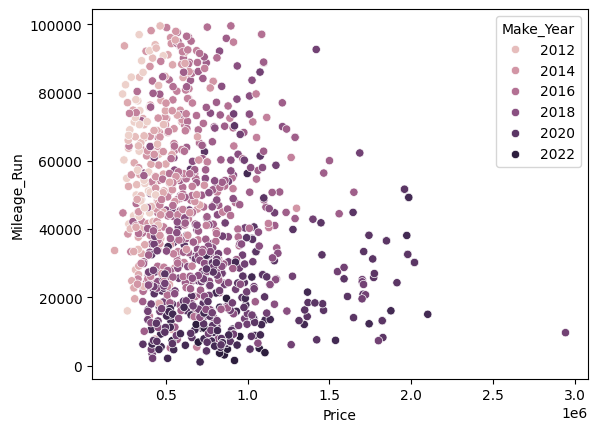

In [11]:
# price vs. mileage, stratified by year
sns.scatterplot(data=cars_data, x="Price", y="Mileage_Run", hue="Make_Year")
# obviously, older cars have higher mileage. 
# newer cars tend to be more expensive, and cars with less mileage tend to be more expensive...
# ...this should be a given, somewhat. 

<Axes: xlabel='Price', ylabel='Mileage_Run'>

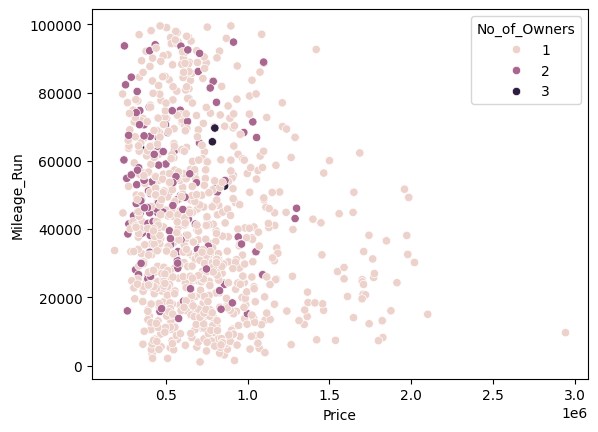

In [12]:
# price vs. mileage stratified by no. of owners
sns.scatterplot(data=cars_data, x="Price", y="Mileage_Run", hue="No_of_Owners")
# obviously, more owners means more mileage, though this correlation does not seem...
# ...HORRIBLY strong. 
# price decreases with use overall, though. (maybe? my eyeballing might not be accurate)

In [13]:
# normalising price values because the kdeplot was lookin real ugly
cars_data["normalised_price"] = np.arcsinh(cars_data["Price"])

<Axes: xlabel='normalised_price', ylabel='Density'>

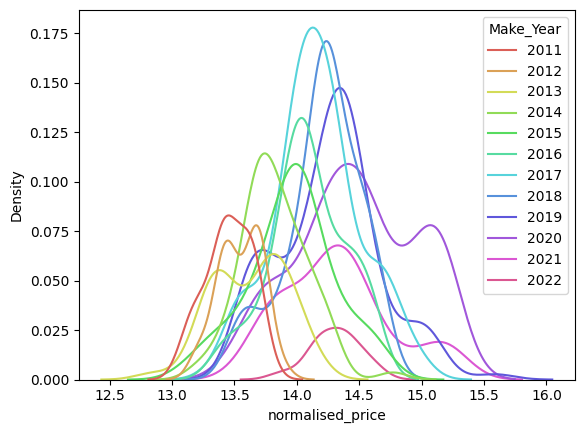

In [14]:
# price kernel density estimate stratified by make year
palette = sns.color_palette("hls", 12)
sns.kdeplot(data=cars_data, x="normalised_price", hue="Make_Year", palette=palette)
# i'm actually surprised by the fact that newest cars are not always...
# ...the most likely to be the most expensive. 
# i'm surprised that 2020's cars are that pricey

<Axes: xlabel='Price', ylabel='Make'>

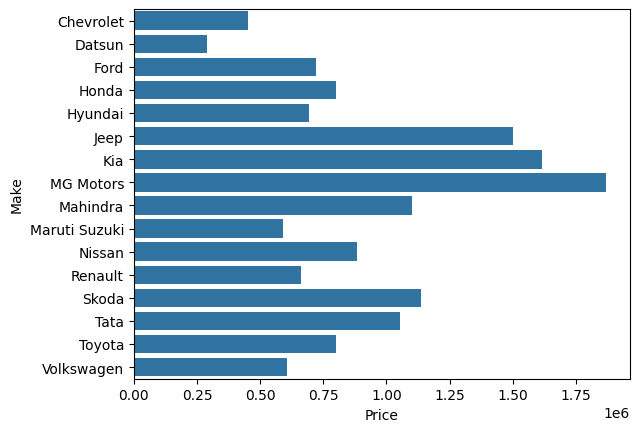

In [15]:
# can i graph mean price? 
mean_prices = cars_data.groupby("Make")["Price"].mean()
sns.barplot(mean_prices, orient="h")
# yes i can! mg motors is the most expensive 

# i wish there was a way to plot the average amount people spend on a car too. 

In [16]:
# oops gotta get rid of normalised price 
cars_data = cars_data.drop(columns=["normalised_price"])

### part two

In [17]:
# fun magic thing called one-hot encoding! 

# making list of categorical variables 
categorical_variables = []
for i in columns:
    if (isinstance(cars_data[i][0], str)) == True:
        categorical_variables.append(i) 

In [18]:
# returning list for troubleshooting
categorical_variables

['Make',
 'Color',
 'Body_Type',
 'Fuel_Type',
 'Transmission',
 'Transmission_Type']

In [19]:
encoded_dataframes = []
for i in categorical_variables: 
    df_encoded = pd.get_dummies(cars_data, columns=[i], drop_first=True, dtype =int)
    print(f"encoded dataframe: {i}")
    print(df_encoded.head())

encoded dataframe: Make
   Unnamed: 0  Make_Year   Color  Body_Type  Mileage_Run  No_of_Owners  \
0           1       2017  silver      sedan        44611             1   
1           2       2016     red  crossover        20305             1   
2           3       2019   white        suv        29540             2   
3           4       2017  bronze  hatchback        35680             1   
4           5       2017  orange  hatchback        25126             1   

   Seating_Capacity Fuel_Type Transmission Transmission_Type  ...  Make_Kia  \
0                 5    diesel      7-Speed         Automatic  ...         0   
1                 5    petrol      5-Speed            Manual  ...         0   
2                 5    petrol      5-Speed            Manual  ...         0   
3                 5    petrol      5-Speed            Manual  ...         0   
4                 5    petrol      5-Speed            Manual  ...         0   

   Make_MG Motors  Make_Mahindra  Make_Maruti Suzuki  Ma

In [20]:
# genuine sheer hatred. 
# there's a way to make this easier. 
# python isn't useful without its packages after all! 
from sklearn.preprocessing import OneHotEncoder

In [21]:
# code i """"drew inspiration from"""" from geeksforgeeks lol 
# https://www.geeksforgeeks.org/ml-one-hot-encoding/

# using the one hot encoder tool 
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(cars_data[categorical_variables])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_variables))

# concatenating to our dataframe
cars_data_encoded = pd.concat([cars_data, one_hot_df], axis=1)
cars_data_encoded = cars_data_encoded.drop(categorical_variables, axis=1)

# looking at what we got 
cars_data_encoded.head()
# nice it worked. 

# one hot encoding will help us predict the likelihood something is or isn't something
# that's kinda how it works under the hood. 

,Unnamed: 0,Make_Year,Mileage_Run,No_of_Owners,Seating_Capacity,Price,Make_Chevrolet,Make_Datsun,Make_Ford,Make_Honda,...,Fuel_Type_diesel,Fuel_Type_petrol,Fuel_Type_petrol+cng,Transmission_4-Speed,Transmission_5-Speed,Transmission_6-Speed,Transmission_7-Speed,Transmission_CVT,Transmission_Type_Automatic,Transmission_Type_Manual
0,1,2017,44611,1,5,657000,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2,2016,20305,1,5,682000,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,3,2019,29540,2,5,793000,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,4,2017,35680,1,5,414000,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,5,2017,25126,1,5,515000,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### question three

In [22]:
# we will need to train-test-split the data
from sklearn.model_selection import train_test_split

In [23]:
# what is our target data? price, so we will put that as our 'y'. 
target_data = cars_data_encoded["Price"]

In [24]:
# our feature matrix. 
feature_matrix = cars_data_encoded.drop(columns="Price")

In [25]:
# we gotta normalise the stuff in our feature matrix...
# ...defining normalisation function 
def maxmin(z):
    z = (z-min(z))/(max(z)-min(z))
    return(z)

In [26]:
# normalising the data
normalised_X = feature_matrix.apply(maxmin)

In [27]:
# train test split
X_train, X_test, Y_train, Y_test = train_test_split(normalised_X, target_data, test_size=0.2, random_state=42) 

In [28]:
# surveying the new data
# that sure is normalised alright
X_train.head()

,Unnamed: 0,Make_Year,Mileage_Run,No_of_Owners,Seating_Capacity,Make_Chevrolet,Make_Datsun,Make_Ford,Make_Honda,Make_Hyundai,...,Fuel_Type_diesel,Fuel_Type_petrol,Fuel_Type_petrol+cng,Transmission_4-Speed,Transmission_5-Speed,Transmission_6-Speed,Transmission_7-Speed,Transmission_CVT,Transmission_Type_Automatic,Transmission_Type_Manual
679,0.696410,0.636364,0.171664,0.0,0.25,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
625,0.641026,0.181818,0.472921,0.5,0.25,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
33,0.033846,0.909091,0.124743,0.0,0.25,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
31,0.031795,0.181818,0.096912,0.0,0.25,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
883,0.905641,0.545455,0.356696,0.0,0.25,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


### question four

In [29]:
# to choose what variables i want to use, i'd like to make a correlation matrix...
# ...with the data
cars_data_corr = cars_data_encoded.corr()
cars_data_corr["Price"].sort_values(ascending=False)
# seems like being an SUV makes you more expensive 

# why is normalised price not one-to-one

Price                          1.000000
Body_Type_suv                  0.613516
Make_MG Motors                 0.592776
Transmission_6-Speed           0.532836
Make_Year                      0.528225
Fuel_Type_diesel               0.386179
Make_Kia                       0.216351
Transmission_7-Speed           0.213658
Transmission_Type_Automatic    0.173321
Color_black                    0.148397
Make_Mahindra                  0.134091
Make_Tata                      0.132952
Make_Jeep                      0.132530
Color_white                    0.108903
Body_Type_sedan                0.103113
Make_Skoda                     0.077201
Seating_Capacity               0.071999
Color_brown                    0.046677
Make_Honda                     0.044882
Make_Toyota                    0.037546
Transmission_CVT               0.030800
Color_red                      0.030629
Make_Nissan                    0.025027
Color_maroon                   0.020768
Unnamed: 0                     0.009313


#### single linear regression 
Three variables I will select for singular linear regression are: 
- Brand (Make).
- Transmission.
- Body type.

i also need to calculate
- R-squared. (Coefficient of determination) 
- RMSE. (Root mean squared error)

In [30]:
# singular linear reg function from codebook, 
# but using it to find y-hats. 
def y_hat(x,y): 
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    b1 = np.inner(x-x_bar,y-y_bar)/np.inner(x-x_bar,x)
    b0 = y_bar - b1*x_bar
    y_hat = b0 + b1*x
    return y_hat

In [31]:
# import linear reg package
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error

### isolate dummies from make ###
# this model is on car brand. 
# train
X_train_make_cols = [col for col in pd.DataFrame(X_train).columns if 'Make' in col]
X_train_make = X_train[X_train_make_cols]
# test
X_test_make_cols = [col for col in pd.DataFrame(X_test).columns if 'Make' in col]
X_test_make = X_test[X_test_make_cols] 

### regression part ###
# train - r squared
reg = LinearRegression(fit_intercept=False).fit(X_train_make, Y_train) # Fit the linear model
print('R-squared (train): ', reg.score(X_train_make, Y_train))

# train - RMSE
Y_hat_train = reg.predict(X_train_make) # chatgpt told me to use this
mse_train = mean_squared_error(Y_train, Y_hat_train)
print('Root mean squared error (train): ', np.sqrt(mse_train))
results = pd.DataFrame({'variable':reg.feature_names_in_, 'coefficient': reg.coef_}) # Regression coefficients

# test - r squared
reg = LinearRegression(fit_intercept=False).fit(X_test_make, Y_test) # Fit the linear model
print('R-squared (test): ', reg.score(X_test_make, Y_test))

# test - RMSE
Y_hat_test = reg.predict(X_test_make)
mse_test = mean_squared_error(Y_test, Y_hat_test)
print('Root mean squared error (test): ', np.sqrt(mse_test))
results = pd.DataFrame({'variable':reg.feature_names_in_, 'coefficient': reg.coef_}) # Regression coefficients

R-squared (train):  0.6748444792832343
Root mean squared error (train):  213038.49809915177
R-squared (test):  0.668081661724963
Root mean squared error (test):  195114.15629675143


In [32]:
### isolate dummies from transmission ###
# this model is on transmission LEVEL.  
# train
X_train_transmission_cols = [col for col in pd.DataFrame(X_train).columns if 'Speed' in col]
X_train_transmission = X_train[X_train_transmission_cols]
# test
X_test_transmission_cols = [col for col in pd.DataFrame(X_test).columns if 'Speed' in col]
X_test_transmission = X_test[X_test_transmission_cols] 

### regression part ###
# train - r squared
reg = LinearRegression(fit_intercept=False).fit(X_train_transmission, Y_train) # Fit the linear model
print('R-squared (train): ', reg.score(X_train_transmission, Y_train))

# train - RMSE
Y_hat_train = reg.predict(X_train_transmission) # chatgpt told me to use this
mse_train = mean_squared_error(Y_train, Y_hat_train)
print('Root mean squared error (train): ', np.sqrt(mse_train))
results = pd.DataFrame({'variable':reg.feature_names_in_, 'coefficient': reg.coef_}) # Regression coefficients

# test - r squared
reg = LinearRegression(fit_intercept=False).fit(X_test_transmission, Y_test) # Fit the linear model
print('R-squared (test): ', reg.score(X_test_transmission, Y_test))

# test - RMSE
Y_hat_test = reg.predict(X_test_transmission)
mse_test = mean_squared_error(Y_test, Y_hat_test)
print('Root mean squared error (test): ', np.sqrt(mse_test))
results = pd.DataFrame({'variable':reg.feature_names_in_, 'coefficient': reg.coef_}) # Regression coefficients

R-squared (train):  0.33273829061689564
Root mean squared error (train):  305183.20349458844
R-squared (test):  0.2943647909056065
Root mean squared error (test):  284487.5583155048


In [33]:
### isolate dummies from body type ###
# this model is on body type. 
# train
X_train_body_cols = [col for col in pd.DataFrame(X_train).columns if 'Body' in col]
X_train_body = X_train[X_train_body_cols]
# test
X_test_body_cols = [col for col in pd.DataFrame(X_test).columns if 'Body' in col]
X_test_body = X_test[X_test_body_cols] 

### regression part ###
# train - r squared
reg = LinearRegression(fit_intercept=False).fit(X_train_body, Y_train) # Fit the linear model
print('R-squared (train): ', reg.score(X_train_body, Y_train))

# train - RMSE
Y_hat_train = reg.predict(X_train_body) # chatgpt told me to use this
mse_train = mean_squared_error(Y_train, Y_hat_train)
print('Root mean squared error (train): ', np.sqrt(mse_train))
results = pd.DataFrame({'variable':reg.feature_names_in_, 'coefficient': reg.coef_}) # Regression coefficients

# test - r squared
reg = LinearRegression(fit_intercept=False).fit(X_test_body, Y_test) # Fit the linear model
print('R-squared (test): ', reg.score(X_test_body, Y_test))

# test - RMSE
Y_hat_test = reg.predict(X_test_body)
mse_test = mean_squared_error(Y_test, Y_hat_test)
print('Root mean squared error (test): ', np.sqrt(mse_test))
results = pd.DataFrame({'variable':reg.feature_names_in_, 'coefficient': reg.coef_}) # Regression coefficients

R-squared (train):  0.4744033999572571
Root mean squared error (train):  270856.2112473151
R-squared (test):  0.4378166847306163
Root mean squared error (test):  253928.90077002146


The model that did the best was the one that used car make (brand). 

#### multiple linear regression

### question five

In [34]:
# just fetching a 'features matrix' with just numeric values
cars_data_numeric = normalised_X[['Make_Year', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity']]

In [35]:
numeric_columns = ['Make_Year', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity']

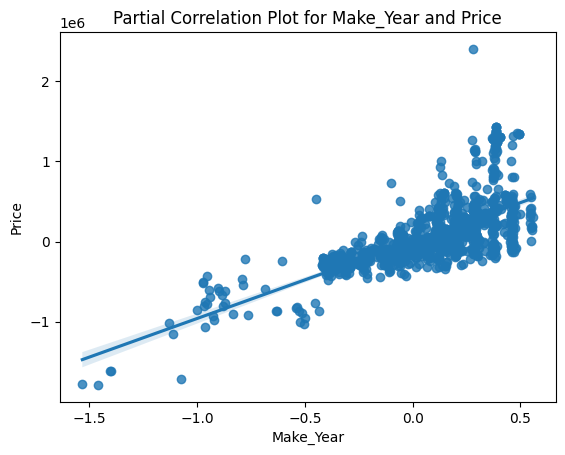

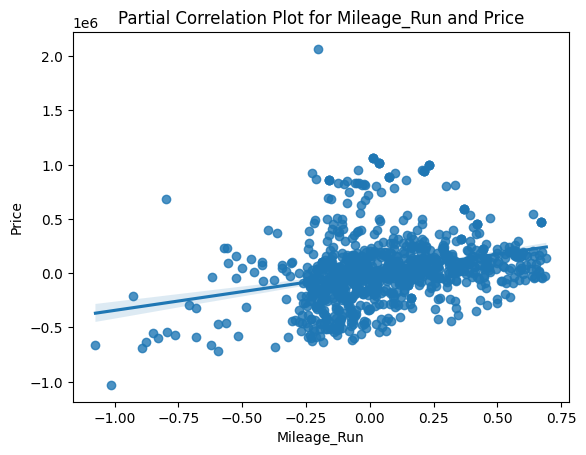

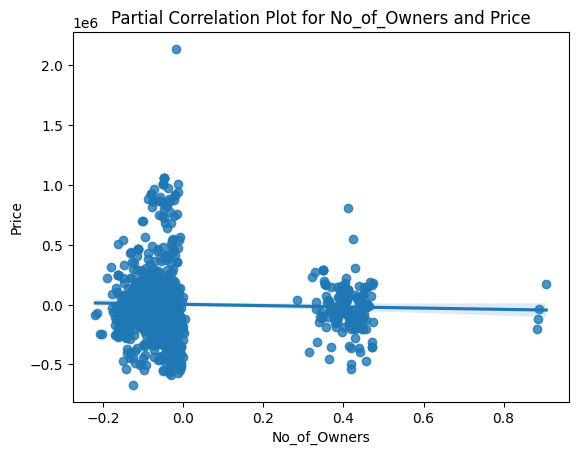

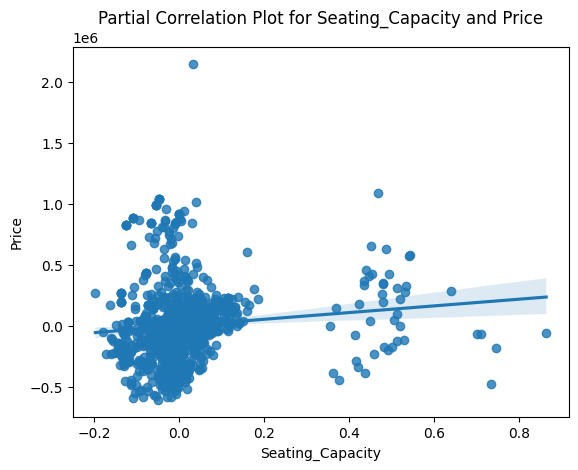

In [36]:
# looping over each part
for i in numeric_columns:
    # make a partial correlation plot for each
    # code stolen from provided codebook 
    var =  i # the variable we are currently using, for the column. 
    x_k = cars_data_numeric[var]
    X_mk = cars_data_numeric.drop(var,axis=1)

    ## 1. Regress y on x\k, save residual r_y
    reg_y = LinearRegression(fit_intercept=False).fit(X_mk, target_data) # Fit the linear model
    r_y = target_data - reg_y.predict(X_mk)

    ## 2. Regress x_k on x\k, save residual r_x
    reg_k = LinearRegression(fit_intercept=False).fit(X_mk, x_k) # Fit the linear model
    r_x = x_k - reg_k.predict(X_mk)

    ## 3. make the correlation plot 
    sns.regplot(y=r_y, x=r_x).set(title=f'Partial Correlation Plot for {i} and Price')
    plt.show()

The relationships between the Make_Year and Price *and* Mileage_Run and Price seem vaguely linear. However, it is difficult to discern a precise linear relationship between Number_of_Owners and Price and Seating_Capacity and Price according to the correlation plots. 

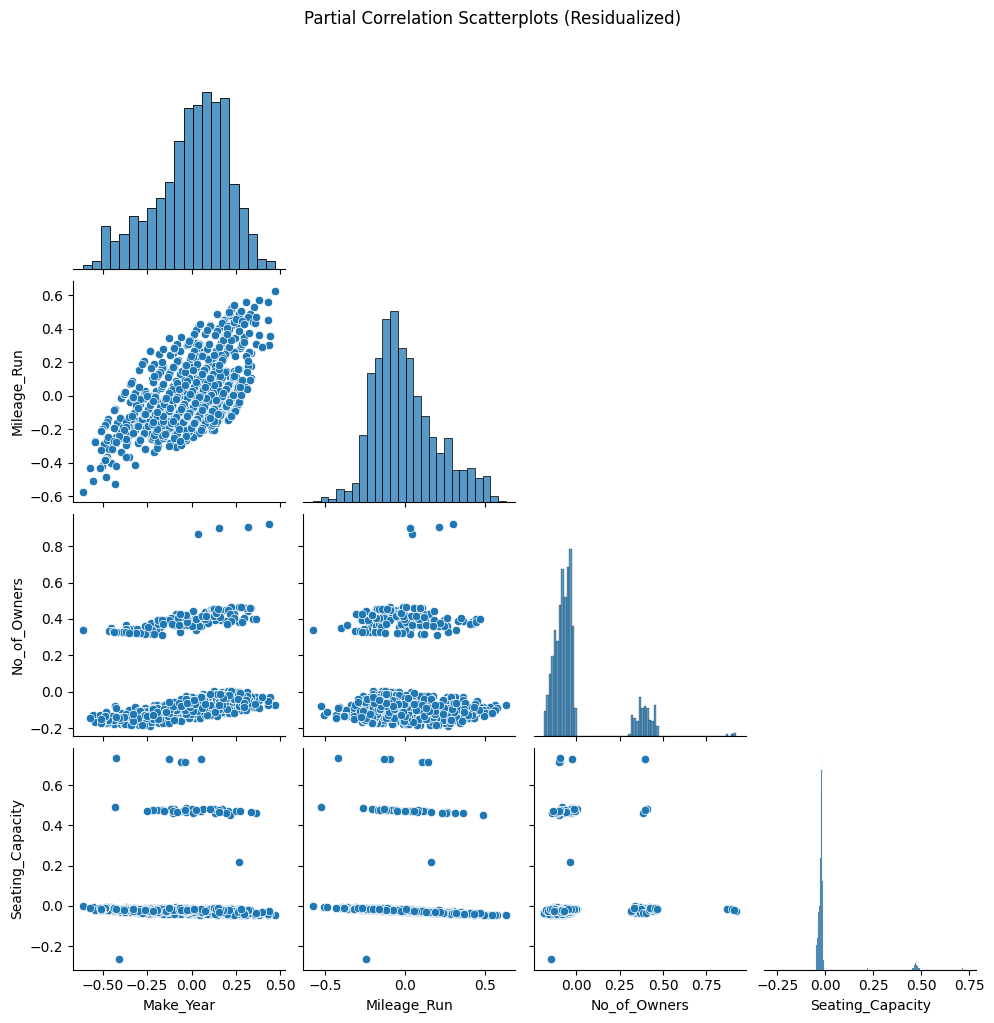

In [37]:
# it's not until now that i realised i misunderstood the first question. 

# this is chatgpt code i am so sorry. 
# i am desperate

# Step 1: Residualize each variable against all others
residuals = pd.DataFrame(index=cars_data_numeric.index)

for col in numeric_columns:
    others = cars_data_numeric.drop(columns=col)
    model = LinearRegression().fit(others, cars_data_numeric[col])
    predicted = model.predict(others)
    residuals[col] = cars_data_numeric[col] - predicted  # residuals = actual - predicted

# Step 2: Pairplot of residuals (partial relationships)
sns.pairplot(residuals, kind='scatter', corner=True)
plt.suptitle('Partial Correlation Scatterplots (Residualized)', y=1.02)
plt.show()

I'm seeing roughly the same relationships.

### question seven
- Question 1: When I did EDA, I noticed that one of the variables that affected price the most was the brand the car was.
- Question 2-3: not much to say here
- Question 4: I saw that there was a mildly strong linear relationship between car make and price; this was the strongest linear relationship out of all the models I built.
- Question 5: I tried to investigate how numeric variables interacted with one another, and I did not see any *complex* non-linear relationships; however, I saw *some* non-linearity. Mileage_run and make_year had linear relationships with one another, however, so if I were to fit a model using all of the numeric variables, there would likely be some multicolinearity. 